In [3]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy


# Hyperparams Constants

In [4]:
normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 100,
    'learning_rate': 0.001,
    'optimizer': optim.Adam,
    # Hyperparameters for diffusion process
    'noise_steps': 500,
    'normalize': True,
    'normalizer':normalizer,
    'scheduler': optim.lr_scheduler.ExponentialLR,
    'ema': EMA(0.99),
    'scheduler_gamma': 0.999,

    # Dataset specific configuration
    'n_paths_per_world': 100000,
    'n_worlds': 1,
}

# Dataloader

In [5]:
from dataset import RobotPathDataset

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### Normalizer

In [7]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_one-world.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'],  normalize=True, normalizer=normalizer, n_worlds=CONFIG['n_worlds'])
print(f' sample shape {dataset[0].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([100000, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0')
 sample shape torch.Size([20, 2]) with 100000 samples


In [8]:
sample

tensor([[-0.9666,  0.7072],
        [-0.9178,  0.7054],
        [-0.8693,  0.7025],
        [-0.8214,  0.6972],
        [-0.7741,  0.6885],
        [-0.7280,  0.6751],
        [-0.6824,  0.6558],
        [-0.6382,  0.6296],
        [-0.5942,  0.5976],
        [-0.5518,  0.5627],
        [-0.5095,  0.5249],
        [-0.4690,  0.4877],
        [-0.4286,  0.4503],
        [-0.3915,  0.4132],
        [-0.3510,  0.3800],
        [-0.3285,  0.3287],
        [-0.3324,  0.1250],
        [-0.3737,  0.0586],
        [-0.4181, -0.0030],
        [-0.4637, -0.0623]], device='cuda:0')

In [9]:
denormalized_sample = normalizer.denormalize(sample)
denormalized_sample

tensor([[0.1671, 8.5362],
        [0.4110, 8.5272],
        [0.6537, 8.5125],
        [0.8930, 8.4861],
        [1.1294, 8.4423],
        [1.3601, 8.3753],
        [1.5882, 8.2791],
        [1.8092, 8.1479],
        [2.0290, 7.9881],
        [2.2412, 7.8133],
        [2.4524, 7.6244],
        [2.6551, 7.4383],
        [2.8568, 7.2516],
        [3.0423, 7.0659],
        [3.2452, 6.9002],
        [3.3575, 6.6436],
        [3.3378, 5.6248],
        [3.1313, 5.2932],
        [2.9094, 4.9849],
        [2.6817, 4.6883]], device='cuda:0')

In [10]:
WORLD_IMG = obstacle_image_i = dataset.world_images[0] # AS WE ARE TRAINING ON 1 WORLD

In [11]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


### Set up Logging

# Model and Diffusion

In [12]:
from model import Diffusion, TemporalUnet

In [13]:
# Create the UNet
transition_dim = sample.shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
model = TemporalUnet(horizon=20, transition_dim=transition_dim)
model.to(device);

[ models/temporal ] Channel dimensions: [(2, 32), (32, 64), (64, 128)]
[(2, 32), (32, 64), (64, 128)]


In [14]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample.shape, noise_steps=CONFIG['noise_steps'])

In [15]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x, timesteps)
y.shape
assert y.shape == (batch_size, 20, 2)

d:\Apps\anaconda\envs\torch-env\lib\site-packages\torch\nn\modules\conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


In [16]:
sample_batch.shape

torch.Size([32, 20, 2])

In [17]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch,timesteps)
x_t.shape, noise.shape

(torch.Size([32, 20, 2]), torch.Size([32, 20, 2]))

tensor([99, 75, 16, 49, 45], device='cuda:0')


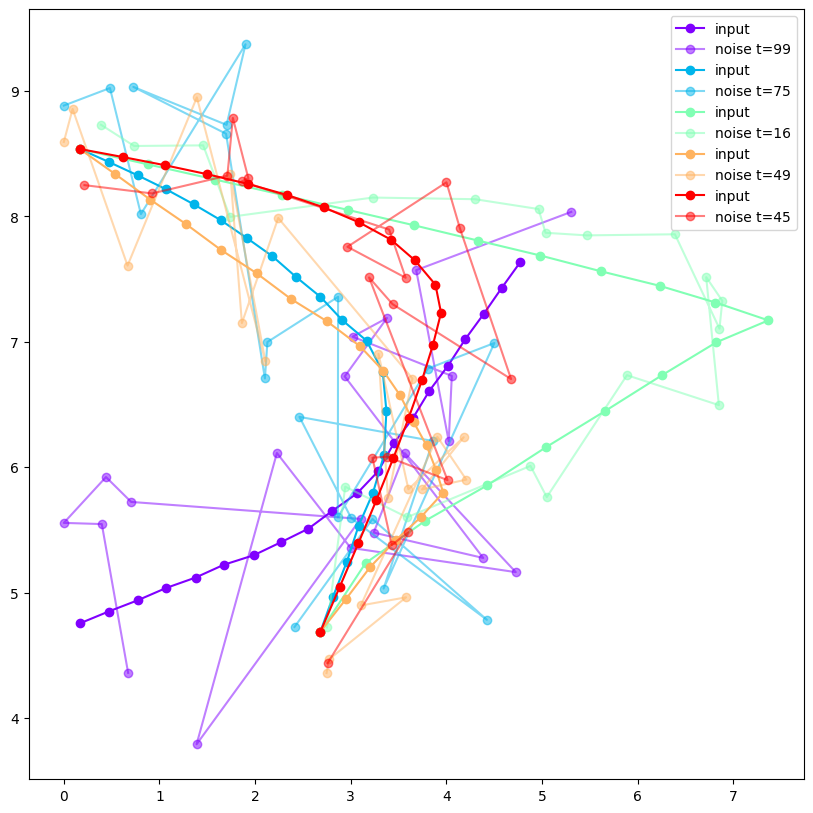

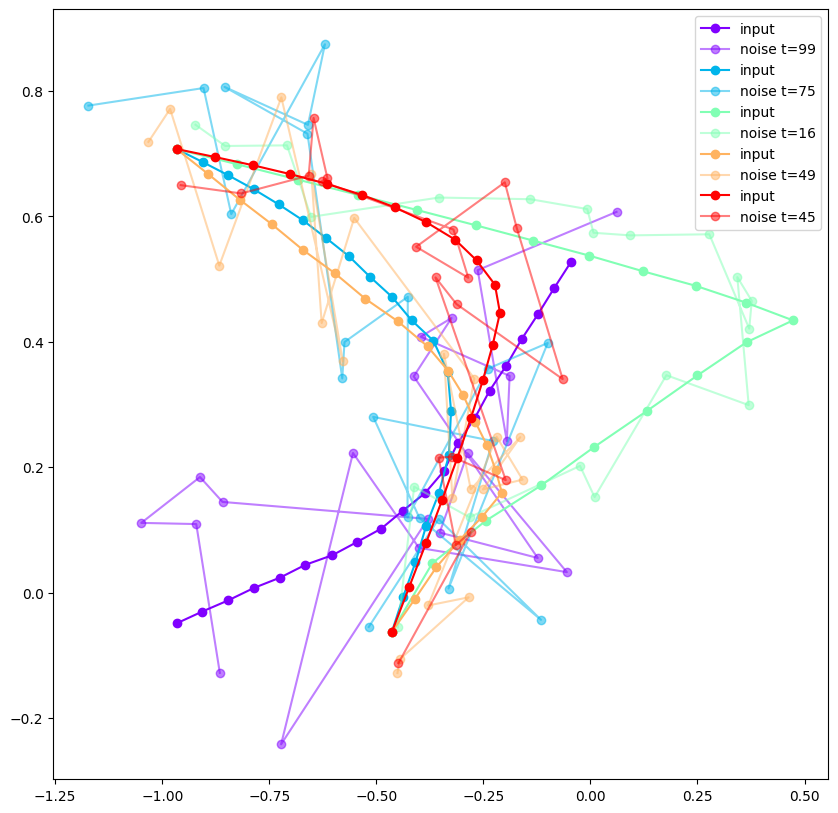

In [18]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch[0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
visualize_diffusion_process(x, x_t, normalizer=normalizer)
visualize_diffusion_process(x, x_t, normalizer=None)


### EMA

# Training

In [19]:
# write training loop 
import torch.optim as optim
import torch.nn as nn


In [20]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name='dummy-path-dataset')
logging_manager.log_config(CONFIG);


Logging to logs\dummy-path-dataset/19h-10m-11-05-2024/logs.log


### Set up validation and plotting function

In [29]:
def plot_diffusions(intermediates, world_img=None, normalizer=None):
    # choose 5 intermediates equally spaced with the last one being at the end indexand 
    intermediates_indx_to_draw = [0, len(intermediates) //4 ,len(intermediates)//2, (3* len(intermediates) ) // 4,len(intermediates)-1]
    if normalizer:
        intermediates = normalizer.denormalize(intermediates, is_numpy=True)
    intermediates = intermediates[intermediates_indx_to_draw]
    intermediates = intermediates.transpose(1,0,2,3)
    number_of_samples = intermediates.shape[0]
    number_of_steps = intermediates.shape[1]
    fig , ax = plt.subplots(number_of_samples,number_of_steps, figsize=(20,20))
    for i, sample in enumerate(intermediates):
        for j, step in enumerate(sample): 
            ax[i, j].plot(step[:, 0], step[:, 1], 'o-', label='l', color='red', alpha=0.8)
            if world_img is not None:
                ax[i, j].imshow(world_img.T, extent=[-0.8, 10.2, -0.8, 10.2], origin='lower', cmap='binary')
             # put 1st point in green and last point in red
            ax[i, j].plot(step[0, 0], step[0, 1], 'o-', label='start', color='green')
            ax[i, j].plot(step[-1, 0], step[-1, 1], 'o-', label='end', color='yellow')
    plt.tight_layout()
    return fig

# plot = plot_diffusions(intermediates, world_img=WORLD_IMG)
# logging_manager.tb_log_figure(plot, 'diffusion_samples')

In [30]:
def plot_noise_and_predicted_noise(sample, noise, predicted_noise, timesteps, normalizer=None):

    # if any of the inputs are in the GPU move them to CPU
    if sample.is_cuda:
        sample = sample.clone().cpu().detach().numpy()
    if noise.is_cuda:
        noise = noise.clone().cpu().detach().numpy()
    if predicted_noise.is_cuda:
        predicted_noise = predicted_noise.clone().cpu().detach().numpy()
    if timesteps.is_cuda:
        timesteps = timesteps.clone().cpu().detach().numpy()

    # get per sample differnce betwen noise and predicted noise MSE
    mse_per_sample = np.mean(np.square(noise - predicted_noise), axis=(1, 2))
    sample_plus_noise = sample + noise
    sample_plus_predicted_noise = sample + predicted_noise
    # denormalize the samples
    if normalizer:
        sample = normalizer.denormalize(sample, is_numpy=True)
        sample_plus_noise = normalizer.denormalize(sample_plus_noise, is_numpy=True)
        sample_plus_predicted_noise = normalizer.denormalize(sample_plus_predicted_noise, is_numpy=True)
    n_cols = 5
    n_rows = sample.shape[0] // n_cols
    fig, ax = plt.subplots(n_rows , n_cols, figsize=(20, 20))
    for i in range(n_rows):
        for j in range(n_cols):
            ax[i, j].plot(sample[j*n_cols + i, :, 0], sample[j*n_cols + i, :, 1], 'o-', label='input', color='blue')
            ax[i, j].plot(sample_plus_noise[j*n_cols + i, :, 0], sample_plus_noise[j*n_cols + i, :, 1], 'o-', label=f'noised', color='green', alpha=0.5)
            ax[i, j].plot(sample_plus_predicted_noise[j*n_cols + i, :, 0], sample_plus_predicted_noise[j*n_cols + i, :, 1], 'o-', label=f'predicted', color='red', alpha=0.5)
            ax[i, j].set_title(f'MSE={mse_per_sample[j*n_cols + i]:.3f}, t={timesteps[j*n_cols + i]}')  # Title for each subplot

    plt.legend()
    return fig


# Train 

In [23]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"D:\Desktop\ADLR\RobotPathData\logs\dummy-path-dataset\14h-13m-11-05-2024\model-epoch_19-loss_0.194-time_14h-30m-11-05-2024"


In [24]:
# train the model

optimizer = CONFIG['optimizer'](model.parameters(), lr=CONFIG['learning_rate'])
scheduler = CONFIG['scheduler'](optimizer, gamma=CONFIG['scheduler_gamma'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')

for epoch in range(CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader))
    running_loss = 0.0
    # iterate over the dataset
    for i, batch in enumerate(pbar):
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen)

        loss = nn.MSELoss()(noise, pred_noise)
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())

        if i % 1000 == 0:
            pbar.set_postfix({'loss': loss.item()})
            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise', step= i + epoch * len(dataloader))
                    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()


    if epoch% 2 == 1:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss, filename='checkpoint.pth')  
        # sample model
        samples, intermediates = diffusion.sample(model,5)
        plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples', step=epoch) 
        # sample ema model
        samples, intermediates = diffusion.sample(ema_model,5)
        plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])
        logging_manager.tb_log_figure(plot, 'diffusion_samples_ema', step=epoch)
         

  0%|          | 0/3125 [00:00<?, ?it/s]d:\Apps\anaconda\envs\torch-env\lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
  0%|          | 0/3125 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [25]:
logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

In [ ]:
# # Save final model
torch.save(model.state_dict(), 'model.pth')

# Sample Model

In [27]:
# load checkpoint
model, _, _, _, _, = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=r'D:\Desktop\ADLR\RobotPathData\logs\dummy-path-dataset\14h-36m-11-05-2024\model-epoch_39-loss_0.121-time_16h-48m-11-05-2024')

99it [00:01, 50.69it/s]


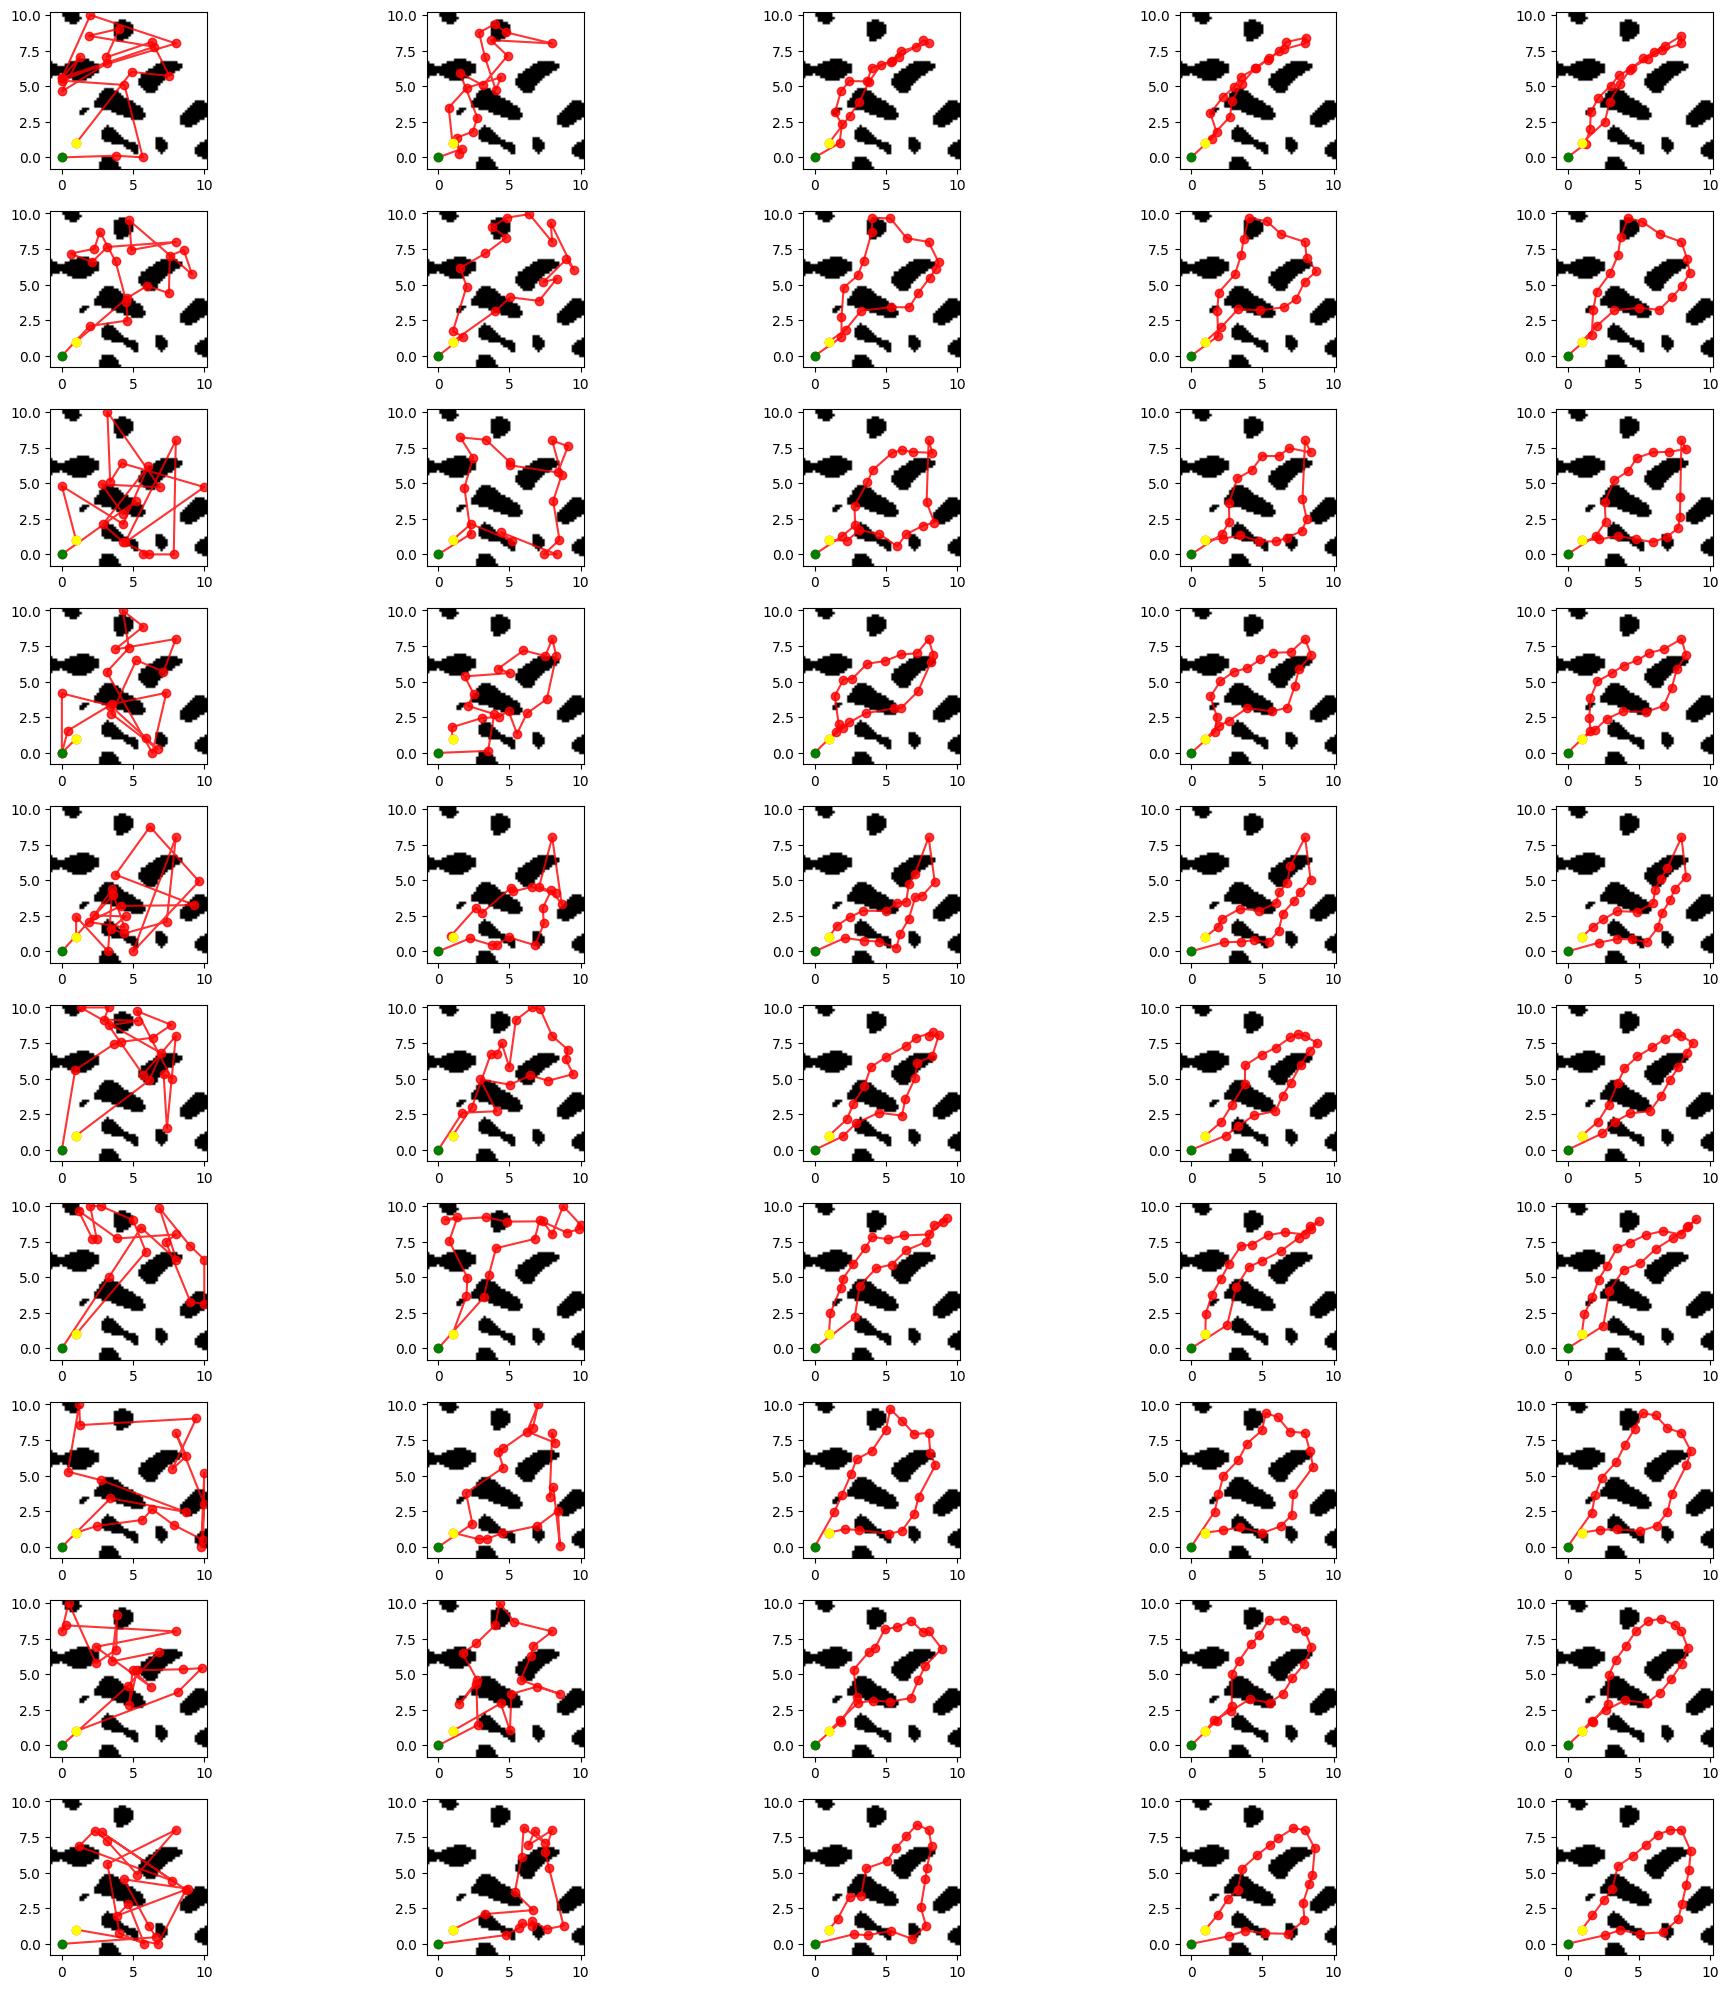

In [39]:
# create constraints dict 
constraints = {
    0: torch.tensor([0, 0], device=device),
    10: torch.tensor([8, 8],device=device),
    19: torch.tensor([1, 1],device=device),
}
# sample from final model
samples, intermediates = diffusion.sample_with_constraints(model, 10, constraints, normalizer=CONFIG['normalizer'])
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])